<a href="https://colab.research.google.com/github/sathvika12-8/Classification_projects/blob/main/KNN_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **KNN Amazon Recommendation System**

# **1.Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

**2. Load the dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Air Conditioners.csv to Air Conditioners.csv
Saving All Appliances.csv to All Appliances.csv
Saving All Books.csv to All Books.csv
Saving All Car and Motorbike Products.csv to All Car and Motorbike Products.csv
Saving All Electronics.csv to All Electronics.csv
Saving All English.csv to All English.csv
Saving All Exercise and Fitness.csv to All Exercise and Fitness.csv
Saving All Grocery and Gourmet Foods.csv to All Grocery and Gourmet Foods.csv
Saving All Hindi.csv to All Hindi.csv
Saving All Home and Kitchen.csv to All Home and Kitchen.csv
Saving All Movies and TV Shows.csv to All Movies and TV Shows.csv
Saving All Music.csv to All Music.csv
Saving All Pet Supplies.csv to All Pet Supplies.csv
Saving All Sports Fitness and Outdoors.csv to All Sports Fitness and Outdoors.csv
Saving All Video Games.csv to All Video Games.csv
Saving Amazon Fashion.csv to Amazon Fashion.csv
Saving Amazon Pharmacy.csv to Amazon Pharmacy.csv
Saving Amazon-Products.csv to Amazon-Products.csv
Saving Bab

In [ ]:

df = pd.read_csv("Amazon-Products.csv")

df.head()

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,"2,255","₹32,999","₹58,990"
1,1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,"2,948","₹46,490","₹75,990"
2,2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,"1,206","₹34,490","₹61,990"
3,3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.0,69,"₹37,990","₹68,990"
4,4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/41lrtqXPiW...,https://www.amazon.in/Carrier-Inverter-Split-C...,4.1,630,"₹34,490","₹67,790"


# **3.Understand the dataset**

In [ ]:
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551585 entries, 0 to 551584
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Unnamed: 0      551585 non-null  int64 
 1   name            551585 non-null  object
 2   main_category   551585 non-null  object
 3   sub_category    551585 non-null  object
 4   image           551585 non-null  object
 5   link            551585 non-null  object
 6   ratings         375791 non-null  object
 7   no_of_ratings   375791 non-null  object
 8   discount_price  490422 non-null  object
 9   actual_price    533772 non-null  object
dtypes: int64(1), object(9)
memory usage: 42.1+ MB


,Unnamed: 0
count,551585.000000
mean,7006.200471
std,5740.835523
min,0.000000
25%,1550.000000
50%,5933.000000
75%,11482.000000
max,19199.000000


# **4.Check the missing values**

In [ ]:
df.isnull().sum()
df.dropna(inplace=True)

# 5: Select Important Features

In [ ]:
data = df[['ratings',
           'no_of_ratings',
           'discount_price',
           'actual_price']].copy()

# **6.Convert data types**

In [ ]:
data['discount_price'] = (
    data['discount_price']
    .astype(str)
    .str.replace('₹','')
    .str.replace(',','')
)

data['actual_price'] = (
    data['actual_price']
    .astype(str)
    .str.replace('₹','')
    .str.replace(',','')
)

# Convert 'no_of_ratings' to numeric by removing commas and coercing errors to NaN
data['no_of_ratings'] = (
    data['no_of_ratings']
    .astype(str)
    .str.replace(',', '')
    .apply(pd.to_numeric, errors='coerce')
)

# Convert 'ratings' to numeric, coercing errors (like 'Get') to NaN
data['ratings'] = pd.to_numeric(data['ratings'], errors='coerce')

data['discount_price'] = data['discount_price'].astype(float)

data['actual_price'] = data['actual_price'].astype(float)

# Drop any rows that resulted in NaN after conversion (e.g., from 'Get' or other non-convertible strings)
data.dropna(inplace=True)

# **7.Feature Scaling**

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

# **8.Build KNN model**

In [ ]:
knn = NearestNeighbors(
    n_neighbors=5,
    metric='euclidean'
)

knn.fit(scaled_data)

NearestNeighbors(metric='euclidean')

# **9.Find similar products**

In [ ]:
product = scaled_data[10].reshape(1,-1)

distance, index = knn.kneighbors(product)

# **10.Display Recommendations**

In [ ]:
recommendations = df.iloc[index[0]]

recommendations

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
959,239,Havells Leganza 4 Blade 1200mm Ceiling Fan (Br...,appliances,All Appliances,https://m.media-amazon.com/images/I/71DvWFLfx4...,https://www.amazon.in/Havells-Leganza-1200mm-C...,4.2,"5,016","₹3,199","₹6,010"
241740,8656,"KDM T-18 Wired Headset (White, in The Ear)","tv, audio & cameras",Headphones,https://m.media-amazon.com/images/I/41LxzV-bGL...,https://www.amazon.in/KDM-T-18-Wired-Headset-W...,3.3,4,₹249,₹399
10,10,"Daikin 1 Ton 3 Star Inverter Split AC (Copper,...",appliances,Air Conditioners,https://m.media-amazon.com/images/I/51Nff1pJMq...,https://www.amazon.in/Daikin-Inverter-Display-...,4.2,558,"₹32,990","₹48,200"
333793,2002,Toyshine Quick Dry Kids Beach Shorts Swim Trun...,kids' fashion,Kids' Fashion,https://m.media-amazon.com/images/I/510aGIPMv7...,https://www.amazon.in/Toyshine-Quick-Beach-Sho...,3.4,11,₹499,₹999
52,52,Lloyd 1.5 Ton 5 Star Fixed Speed Window Ac (Co...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/71wnwaJKh9...,https://www.amazon.in/Lloyd-Window-Copper-Silv...,4.2,474,"₹32,999","₹54,990"


# **11. Visualization**

## **Rating Distribution**

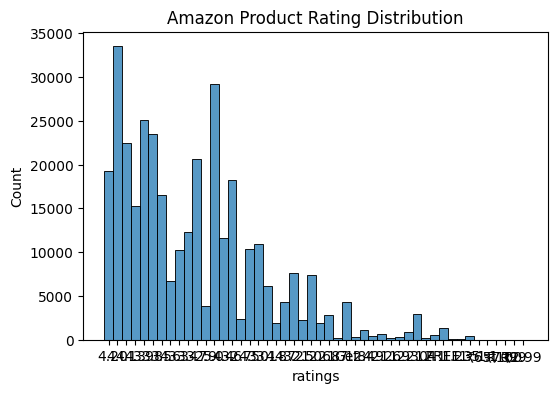

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(df['ratings'])

plt.title("Amazon Product Rating Distribution")

plt.show()

In [ ]:
df.head(10)

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,"2,255","₹32,999","₹58,990"
1,1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,"2,948","₹46,490","₹75,990"
2,2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,"1,206","₹34,490","₹61,990"
3,3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.0,69,"₹37,990","₹68,990"
4,4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/41lrtqXPiW...,https://www.amazon.in/Carrier-Inverter-Split-C...,4.1,630,"₹34,490","₹67,790"
5,5,Voltas 1.4 Ton 3 Star Inverter Split AC(Copper...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/41TuyxwZ9m...,https://www.amazon.in/Voltas-Adjustable-173V-V...,4.0,"1,666","₹31,990","₹70,990"
6,6,Lloyd 1.0 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31IXlxIPsO...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,"1,097","₹29,999","₹49,990"
7,7,Lloyd 1.5 Ton 5 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31IXlxIPsO...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.3,"1,494","₹39,990","₹67,990"
8,8,Carrier 1 Ton 3 Star AI Flexicool Inverter Spl...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51sTXvsanQ...,https://www.amazon.in/Carrier-Flexicool-Invert...,4.1,674,"₹30,990","₹58,190"
9,9,"Voltas 1.5 Ton, 5 Star, Inverter Split AC(Copp...",appliances,Air Conditioners,https://m.media-amazon.com/images/I/51WQ3nWF0v...,https://www.amazon.in/Voltas-Inverter-Split-Co...,4.0,801,"₹37,999","₹73,990"


## **Top 10 Recommended Products Visualization**

/tmp/ipykernel_688/4172768074.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reco_display['name'].apply(lambda x: x[:30] + '...'), y='ratings', data=reco_display, ax=axes[0, 0], palette='viridis', legend=False)
/tmp/ipykernel_688/4172768074.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reco_display['name'].apply(lambda x: x[:30] + '...'), y='no_of_ratings', data=reco_display, ax=axes[0, 1], palette='plasma', legend=False)
/tmp/ipykernel_688/4172768074.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reco_display['name'

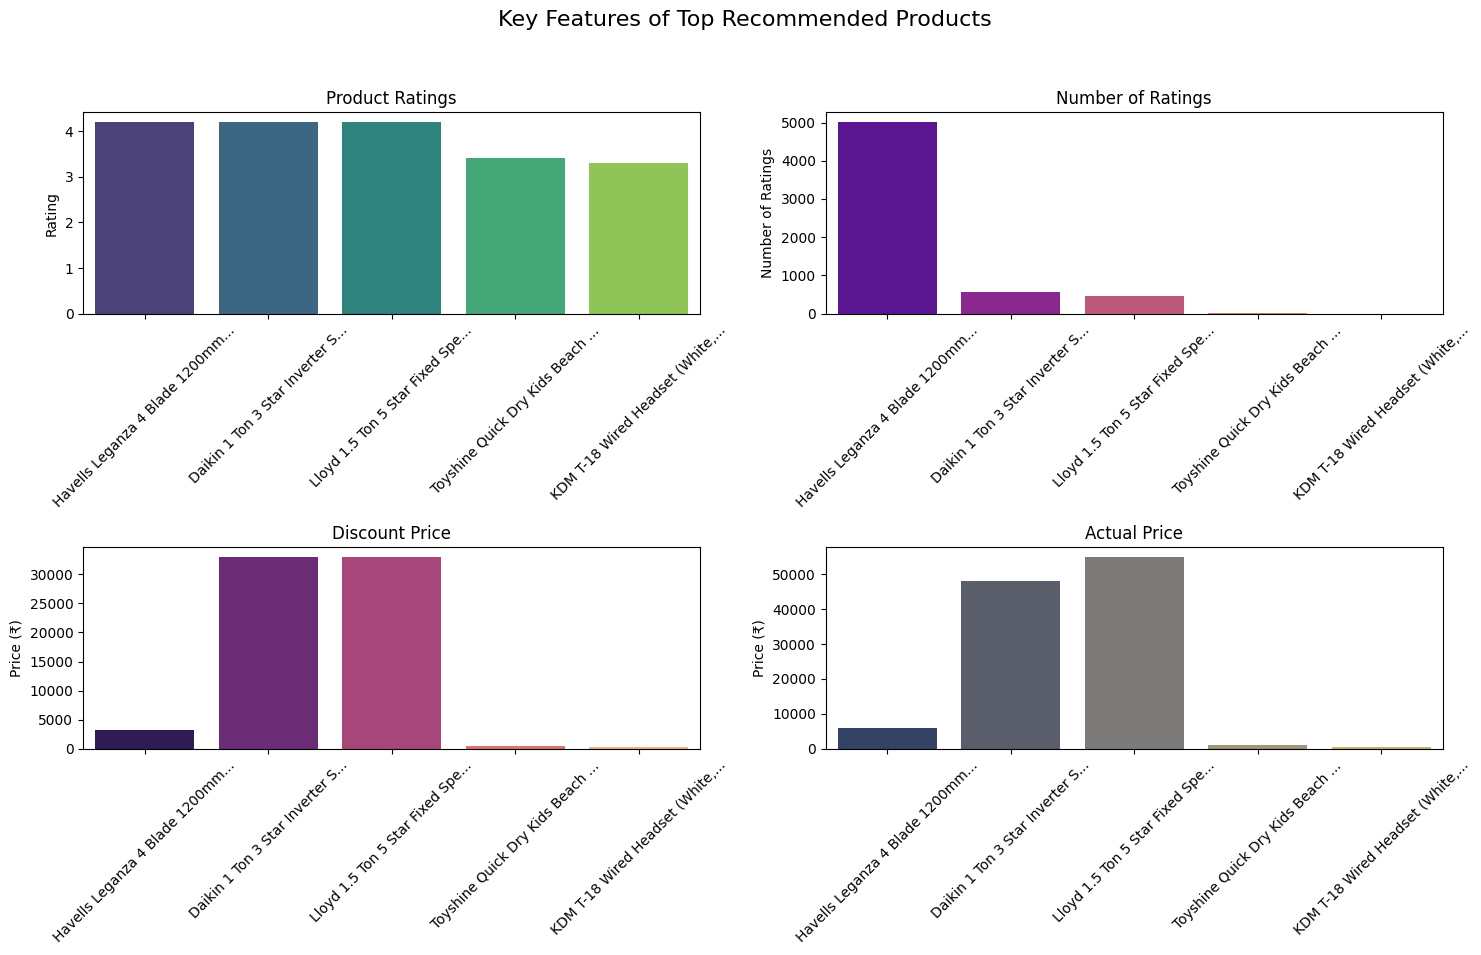

In [ ]:
# To visualize the recommendations, we need to ensure 'ratings' and 'no_of_ratings' are numeric
# They were already converted in the `data` DataFrame, but `recommendations` is sliced from `df`.
# We'll re-convert them for display purposes if they are not already numeric in `recommendations`.

reco_display = recommendations.copy()

# Convert 'no_of_ratings' from object to numeric, handling commas and 'Get' values
reco_display['no_of_ratings'] = (
    reco_display['no_of_ratings']
    .astype(str)
    .str.replace(',', '')
    .apply(pd.to_numeric, errors='coerce')
)

# Convert 'ratings' from object to numeric, handling 'Get' values
reco_display['ratings'] = pd.to_numeric(reco_display['ratings'], errors='coerce')

# Convert 'discount_price' and 'actual_price' to numeric, handling currency and commas
reco_display['discount_price'] = (
    reco_display['discount_price']
    .astype(str)
    .str.replace('₹', '')
    .str.replace(',', '')
    .apply(pd.to_numeric, errors='coerce')
)
reco_display['actual_price'] = (
    reco_display['actual_price']
    .astype(str)
    .str.replace('₹', '')
    .str.replace(',', '')
    .apply(pd.to_numeric, errors='coerce')
)

# Drop any rows that resulted in NaN after conversion for this display DataFrame
reco_display.dropna(inplace=True)

# Sort by ratings for better visualization if there are more than 10
reco_display = reco_display.sort_values(by='ratings', ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Key Features of Top Recommended Products', fontsize=16)

sns.barplot(x=reco_display['name'].apply(lambda x: x[:30] + '...'), y='ratings', data=reco_display, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('Product Ratings')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Rating')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.barplot(x=reco_display['name'].apply(lambda x: x[:30] + '...'), y='no_of_ratings', data=reco_display, ax=axes[0, 1], palette='plasma', legend=False)
axes[0, 1].set_title('Number of Ratings')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Number of Ratings')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.barplot(x=reco_display['name'].apply(lambda x: x[:30] + '...'), y='discount_price', data=reco_display, ax=axes[1, 0], palette='magma', legend=False)
axes[1, 0].set_title('Discount Price')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Price (₹)')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.barplot(x=reco_display['name'].apply(lambda x: x[:30] + '...'), y='actual_price', data=reco_display, ax=axes[1, 1], palette='cividis', legend=False)
axes[1, 1].set_title('Actual Price')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Price (₹)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Pricee Distribution**

## Price Distribution Visualization

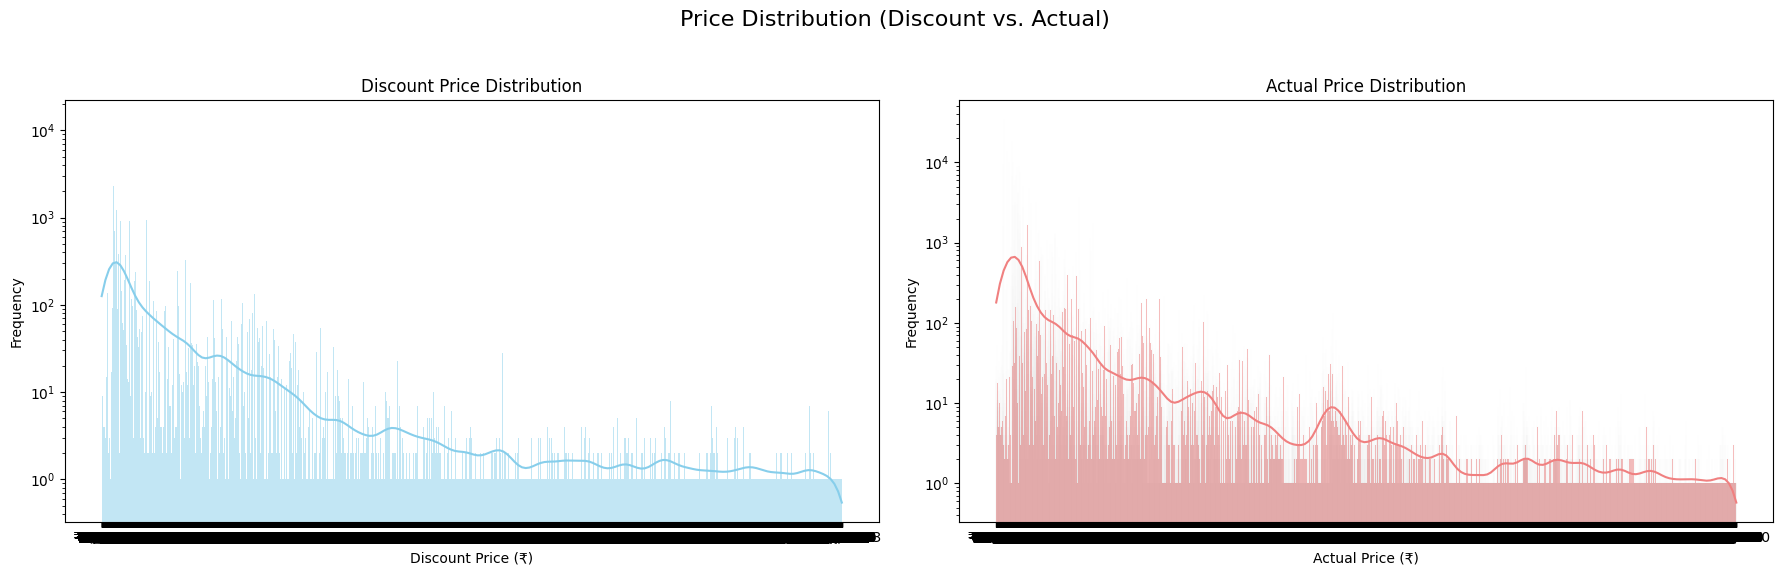

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Price Distribution (Discount vs. Actual)', fontsize=16)

# Discount Price Distribution
sns.histplot(df['discount_price'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Discount Price Distribution')
axes[0].set_xlabel('Discount Price (₹)')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log') # Use log scale due to potential long tail

# Actual Price Distribution
sns.histplot(df['actual_price'], bins=50, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Actual Price Distribution')
axes[1].set_xlabel('Actual Price (₹)')
axes[1].set_ylabel('Frequency')
axes[1].set_yscale('log') # Use log scale due to potential long tail

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**correlation heatmap**

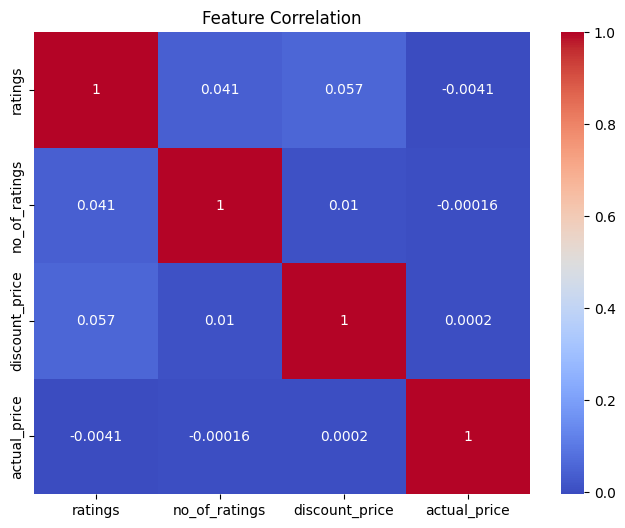

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()